# ML model for assisted labeling

The perpose of this notebook is for me to make a ML model that can predict labels so the labeling process is faster. Firstly I will label one video and train the model on it. Then I will use the model to label one more video, fix txe errors and and train it again with the new and old data.

## Common variables and functions 

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LeaveOneGroupOut
import matplotlib.pyplot as plt
from joblib import dump, load

First we are reading the CSV file containing the data we are using for training. For now this CSV contains only the raw data from the sensors.

In [2]:
data_path = '../data/'
ML_models_path = '../Models/ML/'
merged_df = pd.read_csv(data_path + "Final Training Data/" + "merged_output.csv")
to_label_df = pd.read_csv(data_path + "Final Data For Labeling/" + "merged_output.csv")

In order for the ML model to be able to learn, I have to derive different feachers, like velocity etc.

In [3]:
def compute_features_per_subject(df):
    df = df.sort_values(["recording id", "timestamp [ns]"]).copy()

    # --- Velocity ---
    df["velocity"] = np.nan

    for rec in df["recording id"].unique():
        mask = df["recording id"] == rec
        sub_df = df.loc[mask]

        dx = np.diff(sub_df["gaze x [px]"])
        dy = np.diff(sub_df["gaze y [px]"])
        dt = np.diff(sub_df["time sec"])

        dt[dt == 0] = np.nan

        vel = np.sqrt(dx**2 + dy**2) / dt
        df.loc[mask, "velocity"] = np.append(vel, np.nan)

    # --- Pupil mean (global, safe) ---
    df["pupil mean"] = (
        df["pupil diameter left [mm]"] +
        df["pupil diameter right [mm]"]
    ) / 2

    # --- Pupil normalization per recording ---
    df["pupil norm"] = df.groupby("recording id")["pupil mean"].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-6)
    )

    return df

I will use expanding window as there is concept drift (the distribution of the data changes over time) and this naturally handles it. After playing with the length of the window as well as the overlap, i have found that the following calues work the best.

In [4]:
window_length = 0.22
overlap = 0.0

In [5]:
def create_windows(df, window_size_s, overlap=0.0):
    df = df.sort_values("time sec").reset_index(drop=True)
    times = df["time sec"].values

    stride = window_size_s * (1 - overlap)
    max_time = times[-1]

    windows = []
    start_time = 0.0

    while start_time + window_size_s <= max_time:
        end_time = start_time + window_size_s

        start_idx = np.searchsorted(times, start_time, side="left")
        end_idx = np.searchsorted(times, end_time, side="left")

        if end_idx > start_idx:
            windows.append(df.iloc[start_idx:end_idx])

        start_time += stride

    return windows

In [3]:
def extract_features(window, width=None, height=None):
    features = {}

    vel = window["velocity"].dropna()

    # ------------------------
    # Velocity (existing)
    # ------------------------
    if len(vel) > 0:
        features["vel mean"] = vel.mean()
        features["vel std"] = vel.std()
        features["vel max"] = vel.max()
        features["vel p25"] = np.percentile(vel, 25)
        features["vel p75"] = np.percentile(vel, 75)
    else:
        features["vel mean"] = 0
        features["vel std"] = 0
        features["vel max"] = 0
        features["vel p25"] = 0
        features["vel p75"] = 0

    # ------------------------
    # Event ratios (existing)
    # ------------------------
    features["saccade ratio"] = window["saccade id"].notna().mean()
    features["fixation ratio"] = window["fixation id"].notna().mean()
    features["blink ratio"] = window["blink id"].notna().mean()

    features["num fixations"] = window["fixation id"].nunique()
    features["num saccades"] = window["saccade id"].nunique()

    # =========================================================
    # NEW: Fixation duration features
    # =========================================================
    if "fixation id" in window.columns:
        fix_groups = window.dropna(subset=["fixation id"]).groupby("fixation id")

        fix_durations = fix_groups["timestamp [ms]"].agg(lambda x: x.max() - x.min())

        if len(fix_durations) > 0:
            features["fix dur mean"] = fix_durations.mean()
            features["fix dur std"] = fix_durations.std()
            features["fix dur max"] = fix_durations.max()
            features["fix dur p25"] = np.percentile(fix_durations, 25)
            features["fix dur p75"] = np.percentile(fix_durations, 75)
        else:
            features["fix dur mean"] = 0
            features["fix dur std"] = 0
            features["fix dur max"] = 0
            features["fix dur p25"] = 0
            features["fix dur p75"] = 0
    else:
        features["fix dur mean"] = 0
        features["fix dur std"] = 0
        features["fix dur max"] = 0
        features["fix dur p25"] = 0
        features["fix dur p75"] = 0

    # =========================================================
    # NEW: Saccade amplitude (approximation from gaze path)
    # =========================================================
    if len(window) > 1:
        dx = np.diff(window["gaze x [px]"].values)
        dy = np.diff(window["gaze y [px]"].values)

        sac_amp = np.sqrt(dx**2 + dy**2)

        if len(sac_amp) > 0:
            features["sac amp mean"] = sac_amp.mean()
            features["sac amp std"] = sac_amp.std()
            features["sac amp max"] = sac_amp.max()
        else:
            features["sac amp mean"] = 0
            features["sac amp std"] = 0
            features["sac amp max"] = 0
    else:
        features["sac amp mean"] = 0
        features["sac amp std"] = 0
        features["sac amp max"] = 0

    # =========================================================
    # Existing: event-specific velocity
    # =========================================================
    fix = window[window["fixation id"].notna()]
    sac = window[window["saccade id"].notna()]

    fix_vel = fix["velocity"].dropna()
    sac_vel = sac["velocity"].dropna()

    features["fix vel mean"] = fix_vel.mean() if len(fix_vel) > 0 else 0
    features["sac vel mean"] = sac_vel.mean() if len(sac_vel) > 0 else 0
    features["fix vel std"] = fix_vel.std() if len(fix_vel) > 0 else 0
    features["sac vel std"] = sac_vel.std() if len(sac_vel) > 0 else 0

    # ------------------------
    # Entropy (existing)
    # ------------------------
    hist, _, _ = np.histogram2d(
        window["gaze x [px]"],
        window["gaze y [px]"],
        bins=10
    )
    prob = hist / np.sum(hist) if np.sum(hist) > 0 else hist
    prob = prob[prob > 0]

    features["entropy"] = -np.sum(prob * np.log(prob)) if len(prob) > 0 else 0

    # ------------------------
    # Dispersion (existing)
    # ------------------------
    features["dispersion"] = (
        window["gaze x [px]"].max() - window["gaze x [px]"].min()
    ) + (
        window["gaze y [px]"].max() - window["gaze y [px]"].min()
    )

    # ------------------------
    # Gyro (existing)
    # ------------------------
    gyro_mag = np.sqrt(
        window["gyro x [deg/s]"]**2 +
        window["gyro y [deg/s]"]**2 +
        window["gyro z [deg/s]"]**2
    )

    if len(gyro_mag) > 0:
        features["gyro mag mean"] = gyro_mag.mean()
        features["gyro mag std"] = gyro_mag.std()
        features["gyro mag max"] = gyro_mag.max()
    else:
        features["gyro mag mean"] = 0
        features["gyro mag std"] = 0
        features["gyro mag max"] = 0

    features["head stability"] = (1 / (gyro_mag.std() + 1e-5)) if len(gyro_mag) > 0 else 0
        
    # ------------------------
    # Acceleration (existing)
    # ------------------------
    acc_mag = np.sqrt(
        window["acceleration x [g]"]**2 +
        window["acceleration y [g]"]**2 +
        window["acceleration z [g]"]**2
    )

    if len(acc_mag) > 0:
        features["acc mag mean"] = acc_mag.mean()
        features["acc mag std"] = acc_mag.std()
    else:
        features["acc mag mean"] = 0
        features["acc mag std"] = 0

    # ------------------------
    # Orientation (existing)
    # ------------------------
    features["roll std"] = window["roll [deg]"].std()
    features["pitch std"] = window["pitch [deg]"].std()
    features["yaw std"] = window["yaw [deg]"].std()

    features["yaw range"] = window["yaw [deg]"].max() - window["yaw [deg]"].min()
    features["pitch range"] = window["pitch [deg]"].max() - window["pitch [deg]"].min()

    # ------------------------
    # Jerk (existing)
    # ------------------------
    if len(acc_mag) > 1:
        jerk = np.diff(acc_mag.values)
        features["jerk mean"] = np.mean(np.abs(jerk))
    else:
        features["jerk mean"] = 0

    # ------------------------
    # Pupil (existing)
    # ------------------------
    features["pupil mean"] = window["pupil norm"].mean()
    features["pupil std"] = window["pupil norm"].std()

    # ------------------------
    # Optical axis (existing)
    # ------------------------
    vergence = np.sqrt(
        (window["optical axis left x"] -
         window["optical axis right x"])**2 +

        (window["optical axis left y"] -
         window["optical axis right y"])**2 +

        (window["optical axis left z"] -
         window["optical axis right z"])**2
    )

    features["vergence mean"] = vergence.mean()
    features["vergence std"] = vergence.std()
    
    axis_x = (window["optical axis left x"] + window["optical axis right x"]) / 2
    axis_y = (window["optical axis left y"] + window["optical axis right y"]) / 2
    axis_z = (window["optical axis left z"] + window["optical axis right z"]) / 2

    dx = np.diff(axis_x)
    dy = np.diff(axis_y)
    dz = np.diff(axis_z)

    axis_speed = np.sqrt(dx**2 + dy**2 + dz**2)

    if len(axis_speed) == len(gyro_mag) - 1:

        corr = np.corrcoef(
            axis_speed,
            gyro_mag.iloc[1:]
        )[0, 1]

        features["eye_head_corr"] = (
            corr if not np.isnan(corr) else 0
        )
    else:
        features["eye_head_corr"] = 0
    
    features["axis speed mean"] = np.mean(axis_speed) if len(axis_speed) > 0 else 0
    features["axis speed std"] = np.std(axis_speed) if len(axis_speed) > 0 else 0

    features["axis x std"] = np.std(axis_x)
    features["axis y std"] = np.std(axis_y)
    features["axis z std"] = np.std(axis_z)

    features["axis x range"] = axis_x.max() - axis_x.min()
    features["axis y range"] = axis_y.max() - axis_y.min()
    features["axis z range"] = axis_z.max() - axis_z.min()

    if len(axis_speed) > 1:
        axis_jerk = np.diff(axis_speed)

        features["axis jerk mean"] = np.mean(np.abs(axis_jerk))
        features["axis jerk std"] = np.std(axis_jerk)
        features["axis speed mean"] = np.mean(axis_speed)
        features["axis speed std"] = np.std(axis_speed)
    else:
        features["axis jerk mean"] = 0
        features["axis jerk std"] = 0
        features["axis speed mean"] = 0
        features["axis speed std"] = 0

    hist, _ = np.histogram(axis_z, bins=10)

    prob = hist / hist.sum() if hist.sum() > 0 else hist
    prob = prob[prob > 0]

    features["axis z entropy"] = (
        -np.sum(prob * np.log(prob))
        if len(prob) > 0 else 0
    )
    
    # ------------------------
    # Inside frame (existing)
    # ------------------------
    if width is not None and height is not None:
        inside = (
            (window["gaze x [px]"] >= 0) &
            (window["gaze x [px]"] <= width) &
            (window["gaze y [px]"] >= 0) &
            (window["gaze y [px]"] <= height)
        )
        features["inside ratio"] = inside.mean()

    return features

In [7]:
def prep_train_data(df):
    df = compute_features_per_subject(df)
    windows = create_windows(df, window_length, overlap)

    X = []
    y = []
    groups = []
    
    for window in windows:
        features = extract_features(window)
        X.append(features)

        # label
        label = window["label"].mode()[0]
        y.append(label)

        # group (VERY IMPORTANT)
        group = window["recording id"].iloc[0]
        groups.append(group)

    X = pd.DataFrame(X)
    X = X.fillna(0)
    groups = np.array(groups)
    y = np.array(y)

    return X, y, groups

def prep_to_label_data(df):
    df = compute_features_per_subject(df)
    windows = create_windows(df, window_length, overlap)

    X = []

    for window in windows:
        features = extract_features(window)
        X.append(features)

    X = pd.DataFrame(X)
    X = X.fillna(0)

    return X

In [8]:
def prep_labeled_output(y_pred):
    predicted_df = pd.DataFrame(y_pred, columns=["label"])
    
    # IMPORTANT:
    # Use stride, not full window length, because windows overlap
    stride_s = window_length * (1 - overlap)
    stride_ms = int(stride_s * 1000)

    recording_id = to_label_df["recording id"].iloc[0]
    
    labels = []
    
    last_label = predicted_df.iloc[0]["label"]
    segment_start_ms = 0
    same_label_count = 1
    
    for i in range(1, len(predicted_df)):
        current_label = predicted_df.iloc[i]["label"]
    
        if current_label == last_label:
            same_label_count += 1
            continue
    
        # End current segment
        segment_end_ms = segment_start_ms + (same_label_count * stride_ms)
    
        labels.append((
            recording_id,
            segment_start_ms,
            segment_end_ms,
            last_label
        ))
    
        # Start new segment
        last_label = current_label
        segment_start_ms = segment_end_ms
        same_label_count = 1
    
    
    # Add final segment
    final_end_ms = segment_start_ms + (same_label_count * stride_ms)
    
    labels.append((
        recording_id,
        segment_start_ms,
        final_end_ms,
        last_label
    ))
    
    predicted_df = pd.DataFrame(
        labels,
        columns=[
            "recording id",
            "start timestamp [ms]",
            "end timestamp [ms]",
            "label"
        ]
    )

    return predicted_df

## Random Forest Classifier

In [15]:
X, y, _ = prep_train_data(merged_df)

Firstly I want to create a Random Forest Classifier and see if it can help me, after I have only one labeled recording, to label another one.

In [ ]:
train_sizes = [0.2, 0.4, 0.6, 0.8, 0.9, 0.95]
labels = pd.unique(merged_df["label"])

for t in train_sizes:
    split = int(len(X) * t)
    
    X_train, y_train = X.iloc[:split], y[:split]
    X_test, y_test = X.iloc[split:], y[split:]

    model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features="sqrt", criterion="gini")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.barh(X.columns, model.feature_importances_)
    plt.title("Feature Importance")
    plt.show()
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(xticks_rotation=45)
    plt.tight_layout()
    plt.show()
    
    acc = accuracy_score(y_test, y_pred)

    print(f"\n=== Train size {t:.1f} ===")
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred))

What we can see from the test is that the more labeled data we give it in the training the bigger the accuracy of the model gets. If we train it only on the first 20% of data the accuracy is around 52% while if we train it on 80% of the data, it is going up to around 61%.

Now I will train the model on all of the avalible data and export it.

In [12]:
final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)

final_model.fit(X, y)
dump(final_model, f"{ML_models_path}model_two_training_video.joblib")

['../Models/ML/model_two_training_video.joblib']

In [9]:
model = load(f"{ML_models_path}model_two_training_video.joblib")

In [10]:
new_X = prep_to_label_data(merged_df)

In [11]:
y_pred = model.predict(new_X)
predicted_df = prep_labeled_output(y_pred)
predicted_df.to_csv(data_path + "labels.csv", index=False)

By looking at prediction we can draw the conclusion that one labeled video is far too small of a training data. While during training the accuracy was more then 60%, we can clearly see that we are not geting even 40% on the real data.

Now that I have 2 labeled recordings, i can use the "LeaveOneGroupOut" method, where one of the recordings is left for testing.

In [9]:
X, y, groups = prep_train_data(merged_df)

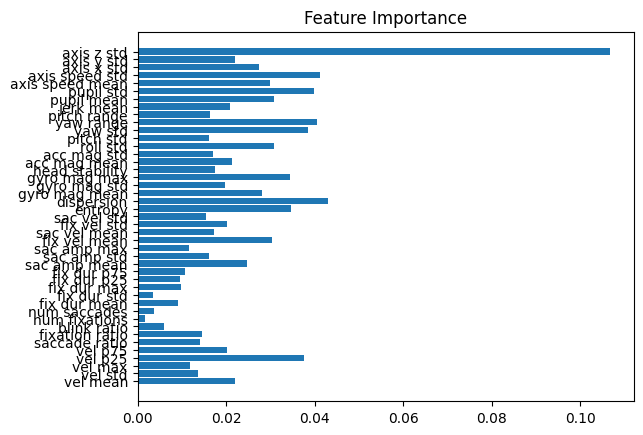

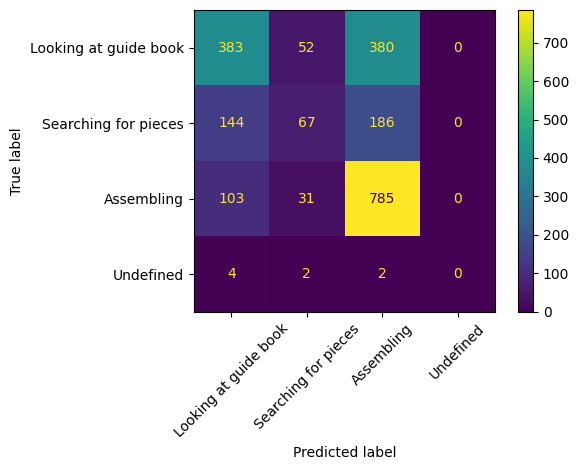

Test subject: 0fc57dc8-de68-4b41-bf69-59a5a5f2d27e
Accuracy: 0.577
                       precision    recall  f1-score   support

           Assembling       0.58      0.85      0.69       919
Looking at guide book       0.60      0.47      0.53       815
 Searching for pieces       0.44      0.17      0.24       397
            Undefined       0.00      0.00      0.00         8

             accuracy                           0.58      2139
            macro avg       0.41      0.37      0.37      2139
         weighted avg       0.56      0.58      0.54      2139

[[0.39195212 0.41331767 0.12625933 0.06847087]
 [0.60549725 0.22711223 0.15053901 0.01685151]
 [0.27195027 0.30604403 0.41085046 0.01115525]
 ...
 [0.66522205 0.19842385 0.13447568 0.00187843]
 [0.74299272 0.18863721 0.06749179 0.00087828]
 [0.55544261 0.31158795 0.08923096 0.04373848]]
[0.41331767 0.60549725 0.41085046 ... 0.66522205 0.74299272 0.55544261]
Accepted: 316/2139


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


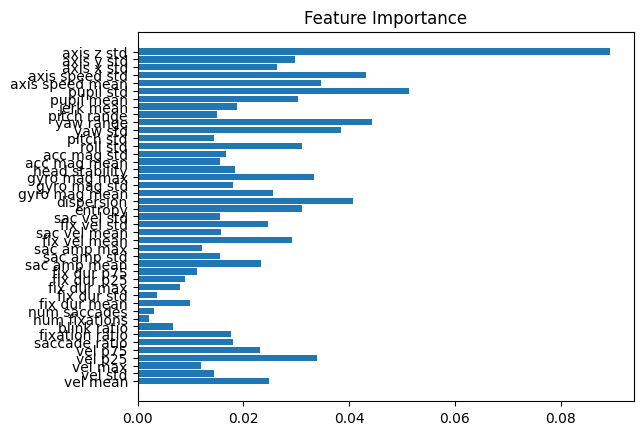

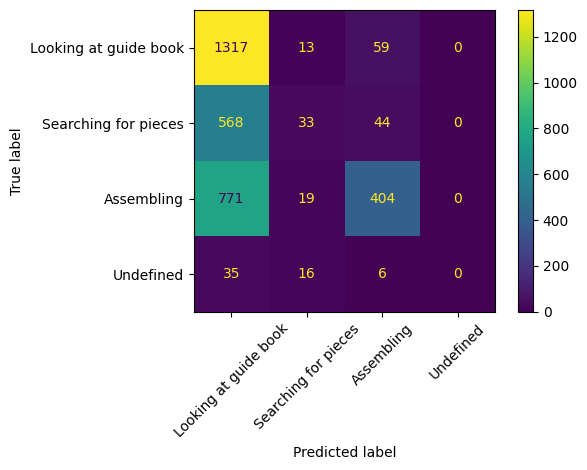

Test subject: 1279952d-14d4-4e77-9010-a000dd546bcd
Accuracy: 0.534
                       precision    recall  f1-score   support

           Assembling       0.79      0.34      0.47      1194
Looking at guide book       0.49      0.95      0.65      1389
 Searching for pieces       0.41      0.05      0.09       645
            Undefined       0.00      0.00      0.00        57

             accuracy                           0.53      3285
            macro avg       0.42      0.33      0.30      3285
         weighted avg       0.57      0.53      0.46      3285

[[0.21780284 0.51049478 0.19193912 0.07976326]
 [0.25303486 0.58079962 0.15135265 0.01481287]
 [0.17957048 0.64613373 0.17050853 0.00378726]
 ...
 [0.27180021 0.56731745 0.15010929 0.01077305]
 [0.24589735 0.52427026 0.19896368 0.0308687 ]
 [0.27165418 0.45380932 0.13174461 0.14279189]]
[0.51049478 0.58079962 0.64613373 ... 0.56731745 0.52427026 0.45380932]
Accepted: 15/3285


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


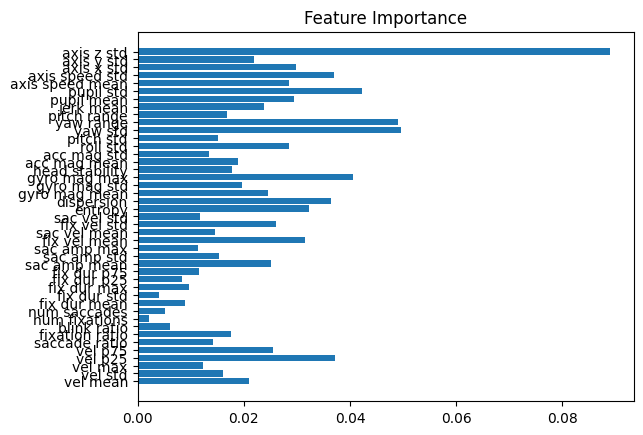

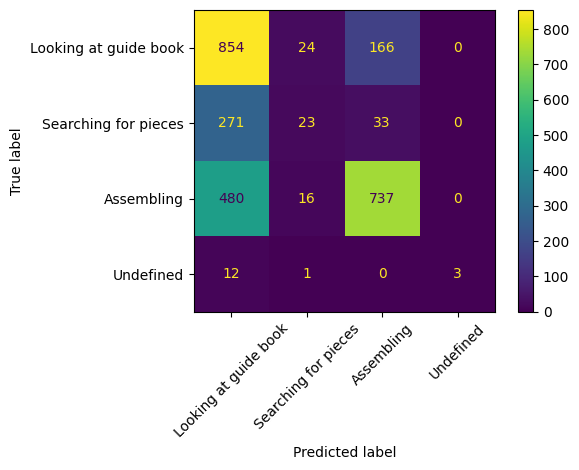

Test subject: 63d66e1c-434f-4f23-8e74-abd8dedc0e43
Accuracy: 0.617
                       precision    recall  f1-score   support

           Assembling       0.79      0.60      0.68      1233
Looking at guide book       0.53      0.82      0.64      1044
 Searching for pieces       0.36      0.07      0.12       327
            Undefined       1.00      0.19      0.32        16

             accuracy                           0.62      2620
            macro avg       0.67      0.42      0.44      2620
         weighted avg       0.63      0.62      0.59      2620

[[0.34395629 0.44848723 0.09760702 0.10994945]
 [0.31684149 0.43105485 0.23617282 0.01593084]
 [0.41707651 0.29776595 0.27432221 0.01083533]
 ...
 [0.47148149 0.33146795 0.14816709 0.04888347]
 [0.18744591 0.52825061 0.17689498 0.1074085 ]
 [0.3128248  0.51427723 0.13443245 0.03846552]]
[0.44848723 0.43105485 0.41707651 ... 0.47148149 0.52825061 0.51427723]
Accepted: 46/2620


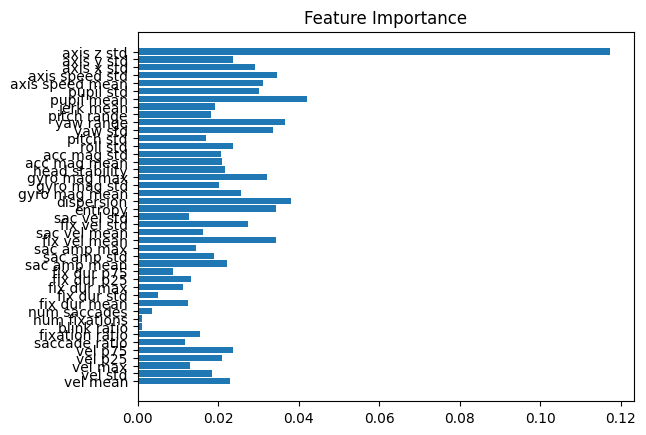

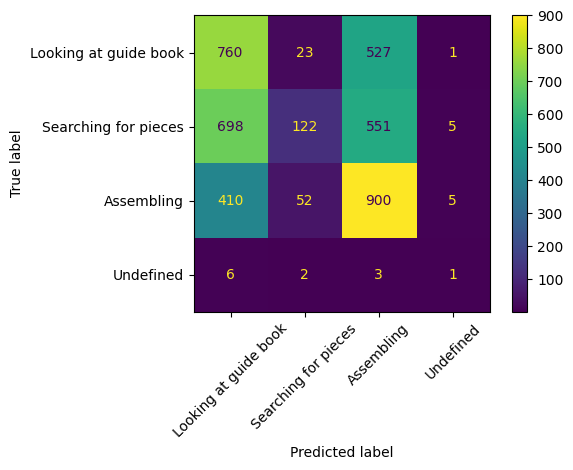

Test subject: 63efffc7-e347-47fb-9615-f7da183d8792
Accuracy: 0.439
                       precision    recall  f1-score   support

           Assembling       0.45      0.66      0.54      1367
Looking at guide book       0.41      0.58      0.48      1311
 Searching for pieces       0.61      0.09      0.15      1376
            Undefined       0.08      0.08      0.08        12

             accuracy                           0.44      4066
            macro avg       0.39      0.35      0.31      4066
         weighted avg       0.49      0.44      0.39      4066

[[0.26699908 0.49400638 0.13977286 0.09922168]
 [0.37875904 0.37458683 0.18318093 0.06347319]
 [0.3164459  0.53277779 0.14424081 0.0065355 ]
 ...
 [0.34394133 0.28337723 0.23960715 0.13307429]
 [0.40604891 0.23850031 0.15388817 0.20156261]
 [0.34553684 0.35755089 0.16080821 0.13610406]]
[0.49400638 0.37875904 0.53277779 ... 0.34394133 0.40604891 0.35755089]
Accepted: 9/4066


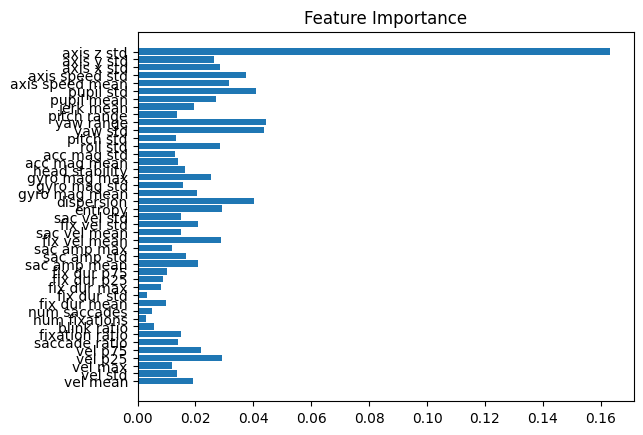

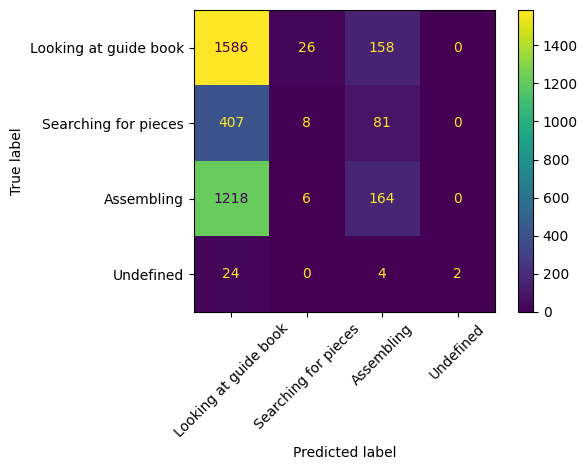

Test subject: f79e6fc3-2075-4b72-b8d6-473f2d2e6694
Accuracy: 0.478
                       precision    recall  f1-score   support

           Assembling       0.40      0.12      0.18      1388
Looking at guide book       0.49      0.90      0.63      1770
 Searching for pieces       0.20      0.02      0.03       496
            Undefined       1.00      0.07      0.12        30

             accuracy                           0.48      3684
            macro avg       0.52      0.27      0.24      3684
         weighted avg       0.42      0.48      0.38      3684

[[0.23871915 0.43010745 0.197073   0.1341004 ]
 [0.45227832 0.3864399  0.13747344 0.02380834]
 [0.23141387 0.43385434 0.33327619 0.0014556 ]
 ...
 [0.41419264 0.52621239 0.05871726 0.0008777 ]
 [0.18438732 0.6050207  0.18810049 0.02249149]
 [0.24649629 0.42384987 0.27769364 0.0519602 ]]
[0.43010745 0.45227832 0.43385434 ... 0.52621239 0.6050207  0.42384987]
Accepted: 787/3684
[316, 15, 46, 9, 787]
Accuracy: 0.577, 0.534, 0

In [10]:
logo = LeaveOneGroupOut()
labels = pd.unique(merged_df["label"])
accuracy = "Accuracy:"
acceptency = []

for train_idx, test_idx in logo.split(X, y, groups):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features="sqrt", criterion="gini")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    probabilities = model.predict_proba(X_test)
    confidences = probabilities.max(axis=1)
    
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.barh(X.columns, model.feature_importances_)
    plt.title("Feature Importance")
    plt.show()
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    
    disp.plot(xticks_rotation=45)
    plt.tight_layout()
    plt.show()
    
    acc = accuracy_score(y_test, y_pred)
    accuracy += f" {acc:.3f},"
    print(f"Test subject: {groups[test_idx][0]}")
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred))
    print(probabilities)
    print(confidences)

    accepted = 0 

    for i in range(0, len(confidences)-1):
        confidence = confidences[i]
        if confidence >= 0.8:
            accepted +=1
    
    print(f"Accepted: {accepted}/{len(confidences)}")
    acceptency.append(accepted)

print(acceptency)
print(accuracy)